<a href="https://colab.research.google.com/github/gjimenexv/Mineria-de-Datos/blob/master/PCA_Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Country-data.csv')
df.set_index('country', inplace = True)
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
import prince

class PCAPrinceVisual:

    def __init__(self, n_components: int = 5, **pca_kwargs) -> None:
        self.n_components = n_components
        self._pca_kwargs = pca_kwargs
        self.pca: prince.PCA | None = None
        self.datos_: pd.DataFrame | None = None
        self._cols_pca: list[str] | None = None

    def fit(self, datos: pd.DataFrame, columnas_pca: list[str] | None = None) -> "PCAPrinceVisual":
        if not isinstance(datos, pd.DataFrame):
            raise TypeError("datos debe ser un pandas.DataFrame.")
        self.datos_ = datos.copy()
        if columnas_pca is None:
            cols = self.datos_.select_dtypes(include=[np.number]).columns.tolist()
        else:
            cols = list(columnas_pca)
            faltan = [c for c in cols if c not in self.datos_.columns]
            if faltan:
                raise KeyError(f"columnas_pca no están en datos: {faltan}")
        if not cols:
            raise ValueError("No hay columnas numéricas para la PCA. Define columnas_pca explícitamente.")
        self._cols_pca = cols
        self.pca = prince.PCA(n_components=self.n_components, **self._pca_kwargs)
        self.pca.fit(self.datos_[self._cols_pca])
        return self

    def _require(self) -> prince.PCA:
        if self.pca is None or self.datos_ is None:
            raise RuntimeError("Llama primero a fit(datos).")
        return self.pca

    # --- 1. Inercia por componente (autovalores y % de varianza explicada) ---
    def plot_inercia(self, ax: plt.Axes | None = None, mostrar_pct: bool = True):
        """Gráfico de inercia: barras de autovalor y, opcionalmente, línea de % acumulado."""
        pca = self._require()
        summary = pca._eigenvalues_summary  # componente, eigenvalue, % varianza
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 4))
        comps = summary.index.astype(str)
        ax.bar(comps, summary["eigenvalue"], color="steelblue", alpha=0.85, label="Autovalor")
        ax.set_xlabel("Componente principal")
        ax.set_ylabel("Autovalor (inercia)")
        ax.set_title("Inercia por componente principal")
        if mostrar_pct:
            ax2 = ax.twinx()
            ax2.plot(
                comps,
                summary[r"% of variance (cumulative)"],
                color="darkorange",
                marker="o",
                linewidth=2,
                label="% varianza acumulada",
            )
            ax2.set_ylabel("% varianza acumulada")
            ax2.set_ylim(0, 105)
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax.legend(h1 + h2, l1 + l2, loc="upper right")
        else:
            ax.legend()
        ax.grid(axis="y", alpha=0.3)
        return ax

    # --- 2. Superposición (individuos + variables en mismas ejes, escala tipo prince) ---
    def plot_superposicion(
        self,
        ejes: tuple[int, int] = (0, 1),
        color_por: str | None = None,
        ax: plt.Axes | None = None,
        etiquetas_individuos: bool = False,
        etiquetas_variables: bool = True,
    ):
        """Mapa factorial: puntos = individuos, cuadrados = variables (coord. escaladas al rango de filas)."""
        pca = self._require()
        X = self.datos_
        i, j = ejes
        row = pca.row_coordinates(X)
        col = pca.column_coordinates_.loc[pca.feature_names_in_].copy()
        escala = np.nanmax(np.abs(row.values))
        if not np.isfinite(escala) or escala == 0:
            escala = 1.0
        col_scaled = col * escala
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 6))
        pct_i = pca.percentage_of_variance_[i]
        pct_j = pca.percentage_of_variance_[j]
        ax.set_xlabel(f"Dim {i} ({pct_i:.1f}% var.)")
        ax.set_ylabel(f"Dim {j} ({pct_j:.1f}% var.)")
        ax.set_title("Superposición individuos–variables")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.axvline(0, color="gray", linewidth=0.8)
        if color_por is not None:
            if color_por not in X.columns:
                raise KeyError(f"{color_por!r} no está en las columnas de X.")
            etiquetas_color = X.loc[row.index, color_por]
            for cat in pd.unique(etiquetas_color):
                sub = row.loc[etiquetas_color == cat]
                ax.scatter(sub[i], sub[j], label=str(cat), alpha=0.75, s=36)
        else:
            ax.scatter(row[i], row[j], alpha=0.75, s=36, c="tab:blue", label="Individuos")
        ax.scatter(
            col_scaled[i],
            col_scaled[j],
            marker="s",
            s=80,
            c="green",
            alpha=0.85,
            label="Variables",
            zorder=5,
        )
        leg = ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        if color_por is not None and leg is not None:
            leg.set_title(color_por)
        if etiquetas_individuos:
            for idx, (xi, yi) in row[[i, j]].iterrows():
                ax.annotate(str(idx), (xi, yi), fontsize=7, alpha=0.7)
        if etiquetas_variables:
            for var, (xi, yi) in col_scaled[[i, j]].iterrows():
                ax.annotate(str(var), (xi, yi), color="darkgreen", fontsize=9, xytext=(4, 4), textcoords="offset points")
        ax.grid(True, alpha=0.3)
        return ax

    # --- 3. Círculo de correlación ---
    def plot_circulo_correlacion(self, ejes: tuple[int, int] = (0, 1), ax: plt.Axes | None = None):
        """Proyección de correlaciones variable–componente en el plano (radio ≤ 1 en PCA estandarizada)."""
        pca = self._require()
        i, j = ejes
        R = pca.column_correlations.loc[pca.feature_names_in_]
        if ax is None:
            _, ax = plt.subplots(figsize=(6.5, 6.5))
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=1, label="Círculo unidad")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.axvline(0, color="gray", linewidth=0.8)
        for var, row in R.iterrows():
            ax.arrow(0, 0, row[i], row[j], head_width=0.02, head_length=0.02, fc="steelblue", ec="steelblue", length_includes_head=True)
            ax.text(row[i] * 1.08, row[j] * 1.08, str(var), fontsize=9)
        pct_i = pca.percentage_of_variance_[i]
        pct_j = pca.percentage_of_variance_[j]
        ax.set_xlabel(f"Correlación con dim {i} ({pct_i:.1f}% var.)")
        ax.set_ylabel(f"Correlación con dim {j} ({pct_j:.1f}% var.)")
        ax.set_title("Círculo de correlación")
        ax.set_aspect("equal")
        lim = 1.05
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.grid(True, alpha=0.3)
        return ax

    # --- 4. Biplot ---
    def plot_biplot(
        self,
        ejes: tuple[int, int] = (0, 1),
        ax: plt.Axes | None = None,
        escala_flechas: float | None = None,
        etiquetas_individuos: bool = False,
        etiquetas_variables: bool = True,
    ):
        """Individuos (coord. principales) + flechas desde el origen proporcionales a las correlaciones."""
        pca = self._require()
        X = self.datos_
        i, j = ejes
        F = pca.row_coordinates(X)
        R = pca.column_correlations.loc[pca.feature_names_in_]
        if escala_flechas is None:
            m = np.nanmax(np.abs(F.values))
            escala_flechas = m if m and np.isfinite(m) else 1.0
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(F[i], F[j], alpha=0.65, s=40, c="tab:blue", edgecolors="none", label="Individuos")
        if etiquetas_individuos:
            for idx, (xi, yi) in F[[i, j]].iterrows():
                ax.annotate(str(idx), (xi, yi), fontsize=7, alpha=0.7)
        for var, row in R.iterrows():
            vx, vy = row[i] * escala_flechas, row[j] * escala_flechas
            ax.arrow(0, 0, vx, vy, head_width=0.03 * escala_flechas, head_length=0.05 * escala_flechas, fc="darkred", ec="darkred", length_includes_head=True, zorder=4)
            if etiquetas_variables:
                ax.text(vx * 1.1, vy * 1.1, str(var), color="darkred", fontsize=9, zorder=5)
        pct_i = pca.percentage_of_variance_[i]
        pct_j = pca.percentage_of_variance_[j]
        ax.set_xlabel(f"Dim {i} ({pct_i:.1f}% var.)")
        ax.set_ylabel(f"Dim {j} ({pct_j:.1f}% var.)")
        ax.set_title("Biplot (scores + loadings de correlación)")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.axvline(0, color="gray", linewidth=0.8)
        ax.grid(True, alpha=0.3)
        ax.legend()
        return ax

    @staticmethod
    def _tabla_a_celdas(df: pd.DataFrame) -> tuple[list[str], list[str], list[list[str]]]:
        """Encabezados de columnas, etiquetas de fila y cuerpo como texto para matplotlib.table."""
        cols = [str(c) for c in df.columns]
        idx = [str(i) for i in df.index]
        body = []
        for _, row in df.iterrows():
            body.append([str(v) for v in row.values])
        return cols, idx, body

    def _dibujar_tabla_en_ax(self, ax: plt.Axes, df: pd.DataFrame, titulo: str, fontsize: float = 8.0) -> plt.Axes:
        ax.clear()
        ax.axis("off")
        ax.set_title(titulo, fontsize=11, loc="left", pad=8)
        cols, idx, body = self._tabla_a_celdas(df)
        tbl = ax.table(
            cellText=body,
            rowLabels=idx,
            colLabels=cols,
            loc="upper left",
            cellLoc="right",
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(fontsize)
        tbl.scale(1.0, 1.35)
        return ax

    # --- 5. Cos² individuos (tabla, mayor → menor por calidad en el plano) ---
    def tabla_cos2_individuos(
        self,
        ejes: tuple[int, int] = (0, 1),
        max_filas: int | None = None,
    ) -> pd.DataFrame:
        """Cos² por dimensión y acumulado en el plano (dim i + dim j); ordenado de mayor a menor cos² en el plano."""
        pca = self._require()
        X = self.datos_
        i, j = ejes
        cos2 = pca.row_cosine_similarities(X)
        df = pd.DataFrame(
            {
                f"cos² dim {i}": cos2[i],
                f"cos² dim {j}": cos2[j],
                f"cos² plano ({i}+{j})": cos2[i] + cos2[j],
            }
        )
        df = df.sort_values(f"cos² plano ({i}+{j})", ascending=False)
        if max_filas is not None:
            df = df.iloc[:max_filas]
        return df

    def plot_tabla_cos2_individuos(
        self,
        ejes: tuple[int, int] = (0, 1),
        ax: plt.Axes | None = None,
        max_filas: int = 35,
    ) -> tuple[plt.Axes, pd.DataFrame]:
        """Dibuja la tabla de cos² en un eje matplotlib (útil dentro de `plot_todos`)."""
        df = self.tabla_cos2_individuos(ejes=ejes, max_filas=max_filas)
        disp = df.copy()
        for c in disp.columns:
            disp[c] = disp[c].apply(lambda x: f"{float(x):.1%}" if pd.notna(x) else "")
        i, j = ejes
        titulo = f"Cos² individuos (mayor → menor en plano dim {i}–dim {j})"
        if ax is None:
            _, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(disp))))
        self._dibujar_tabla_en_ax(ax, disp, titulo)
        return ax, df

    # --- 6. Contribución variables (tabla, mayor → menor dentro de cada dimensión) ---
    def tabla_contribucion_variables(
        self,
        componentes: list[int] | None = None,
        top_k: int | None = None,
    ) -> pd.DataFrame:
        """Filas: cada dimensión con variables ordenadas por contribución (%) de mayor a menor."""
        pca = self._require()
        C = (pca.column_contributions_.loc[pca.feature_names_in_] * 100).copy()
        if componentes is None:
            componentes = list(C.columns)
        bloques: list[pd.DataFrame] = []
        for comp in componentes:
            s = C[comp].sort_values(ascending=False)
            if top_k is not None:
                s = s.head(top_k)
            part = pd.DataFrame(
                {
                    "dimensión": comp,
                    "variable": s.index.astype(str),
                    "contribución (%)": s.values.round(2),
                }
            )
            bloques.append(part)
        return pd.concat(bloques, ignore_index=True)

    def plot_tabla_contribucion_variables(
        self,
        ax: plt.Axes | None = None,
        componentes: list[int] | None = None,
        top_k: int | None = None,
        max_filas: int = 40,
    ) -> tuple[plt.Axes, pd.DataFrame]:
        """Dibuja la tabla de contribuciones (recortada a `max_filas` filas si hace falta)."""
        df = self.tabla_contribucion_variables(componentes=componentes, top_k=top_k)
        if len(df) > max_filas:
            df = df.iloc[:max_filas].copy()
            sufijo = f" (primeras {max_filas} filas; hay más — usa `tabla_contribucion_variables` sin límite)"
        else:
            sufijo = ""
        disp = df.copy()
        disp["contribución (%)"] = disp["contribución (%)"].map(lambda x: f"{x:.1f}%")
        titulo = "Contribución variables por dimensión (mayor → menor en cada dim.)" + sufijo
        if ax is None:
            _, ax = plt.subplots(figsize=(10, max(3, 0.32 * len(disp))))
        self._dibujar_tabla_en_ax(ax, disp, titulo)
        return ax, df

    def plot_todos(
        self,
        color_por: str | None = None,
        etiquetas_individuos: bool = False,
        etiquetas_variables: bool = True,
        ejes: tuple[int, int] = (0, 1),
        max_filas_cos2: int = 30,
        max_filas_contrib: int = 40,
    ):
        """Cuatro gráficos + dos tablas (cos² y contribución) en una sola figura."""
        fig = plt.figure(figsize=(14, 18))
        gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1.1, 1.1])

        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])
        ax2 = fig.add_subplot(gs[1, 0])
        ax3 = fig.add_subplot(gs[1, 1])
        ax4 = fig.add_subplot(gs[2, :])
        ax5 = fig.add_subplot(gs[3, :])

        self.plot_inercia(ax=ax0)
        self.plot_superposicion(
            ax=ax1, color_por=color_por, ejes=ejes,
            etiquetas_individuos=etiquetas_individuos,
            etiquetas_variables=etiquetas_variables,
        )
        self.plot_circulo_correlacion(ejes=ejes, ax=ax2)
        self.plot_biplot(
            ax=ax3, ejes=ejes,
            etiquetas_individuos=etiquetas_individuos,
            etiquetas_variables=etiquetas_variables,
        )
        self.plot_tabla_cos2_individuos(ejes=ejes, ax=ax4, max_filas=max_filas_cos2)
        self.plot_tabla_contribucion_variables(ax=ax5, max_filas=max_filas_contrib)

        plt.tight_layout()
        return fig, (ax0, ax1, ax2, ax3, ax4, ax5)

In [ ]:
vis = PCAPrinceVisual(n_components=5)
vis.fit(df)

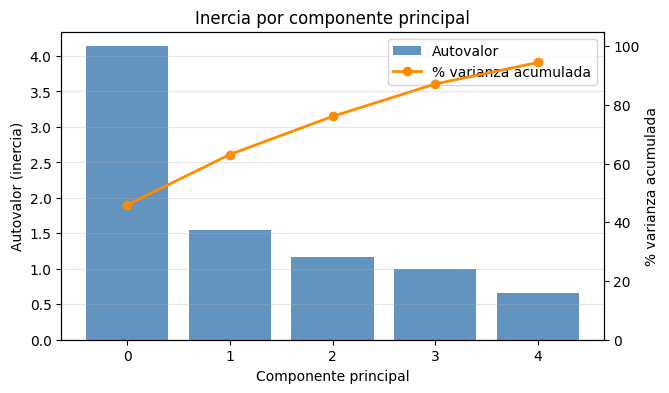

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
vis.plot_inercia(ax=ax)
plt.show()

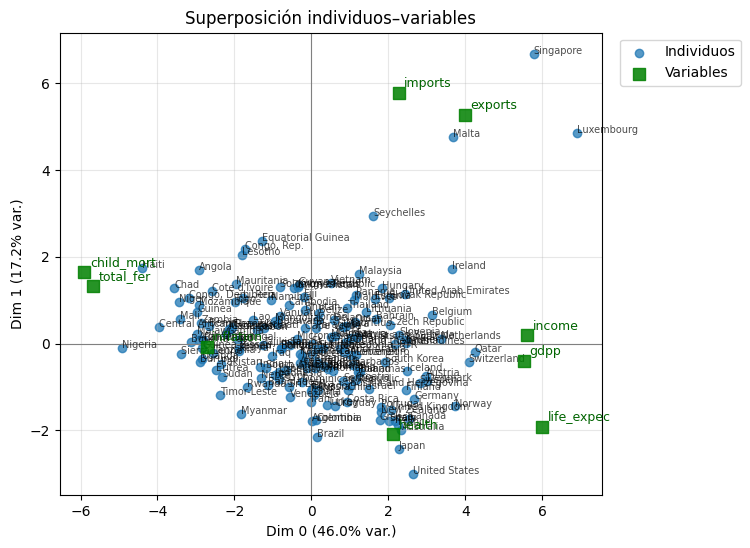

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
vis.plot_superposicion(ax=ax, etiquetas_individuos=True, etiquetas_variables=True)
plt.show()

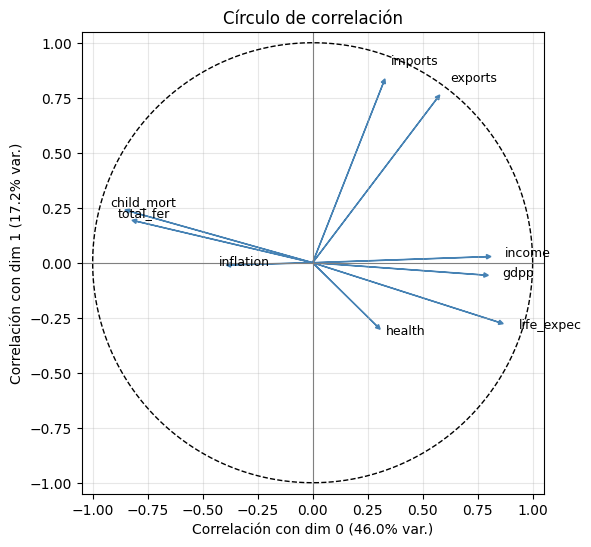

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
vis.plot_circulo_correlacion(ax=ax)
plt.show()

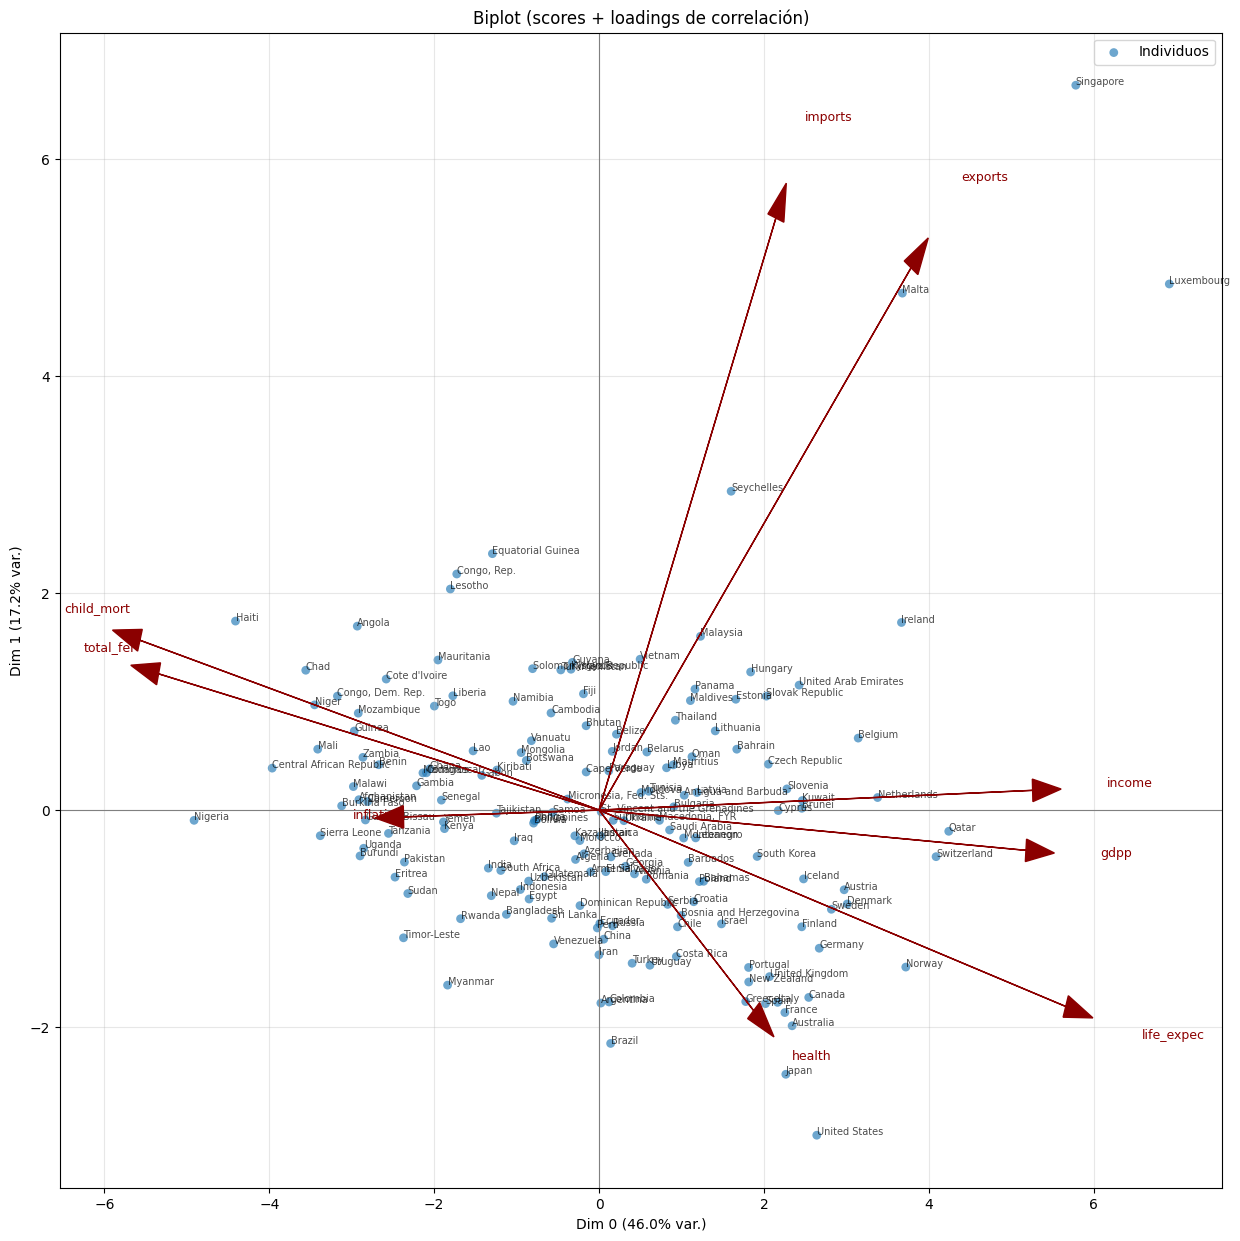

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))
vis.plot_biplot(ax=ax,etiquetas_individuos=True, etiquetas_variables=True)
plt.show()

In [ ]:
vis.tabla_cos2_individuos().style.format("{:.1%}", na_rep="")

,cos² dim 0,cos² dim 1,cos² plano (0+1)
country,,,
Singapore,42.4%,56.7%,99.1%
Spain,53.8%,42.0%,95.8%
Italy,56.4%,37.8%,94.2%
Ghana,90.9%,3.1%,94.0%
Brazil,0.4%,92.8%,93.2%
Guinea,87.9%,5.3%,93.2%
South Korea,87.8%,4.4%,92.2%
Greece,46.2%,45.4%,91.6%
Ireland,74.8%,16.6%,91.4%


In [ ]:
vis.tabla_contribucion_variables().style.format(
    {"contribución (%)": "{:.2f}%"},
    na_rep="",
)

,dimensión,variable,contribución (%)
0,0,life_expec,18.13%
1,0,child_mort,17.60%
2,0,total_fer,16.30%
3,0,income,15.88%
4,0,gdpp,15.42%
5,0,exports,8.06%
6,0,inflation,3.73%
7,0,imports,2.61%
8,0,health,2.28%
9,1,imports,45.13%


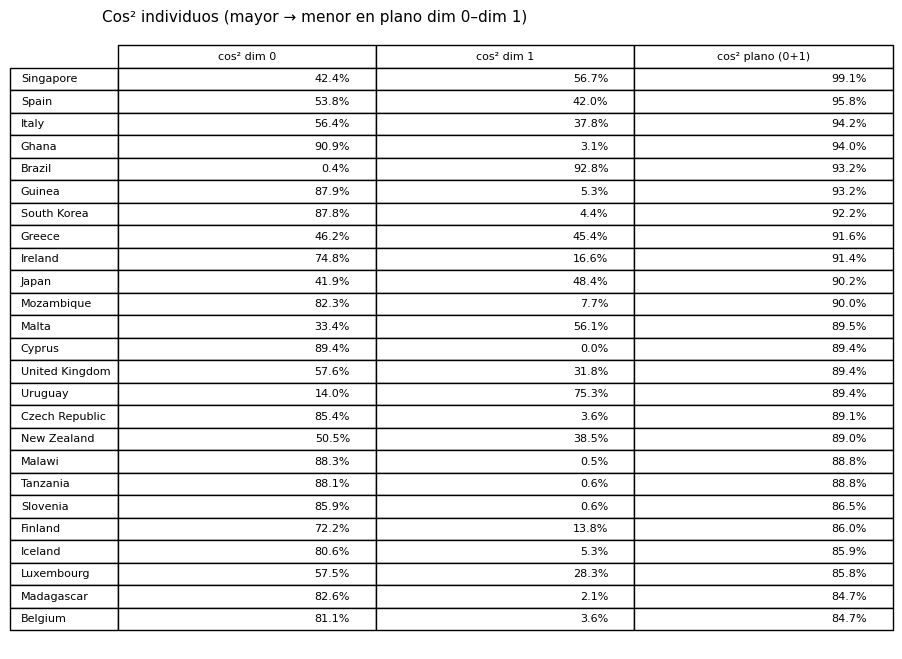

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
vis.plot_tabla_cos2_individuos(ax=ax, max_filas=25)
plt.show()

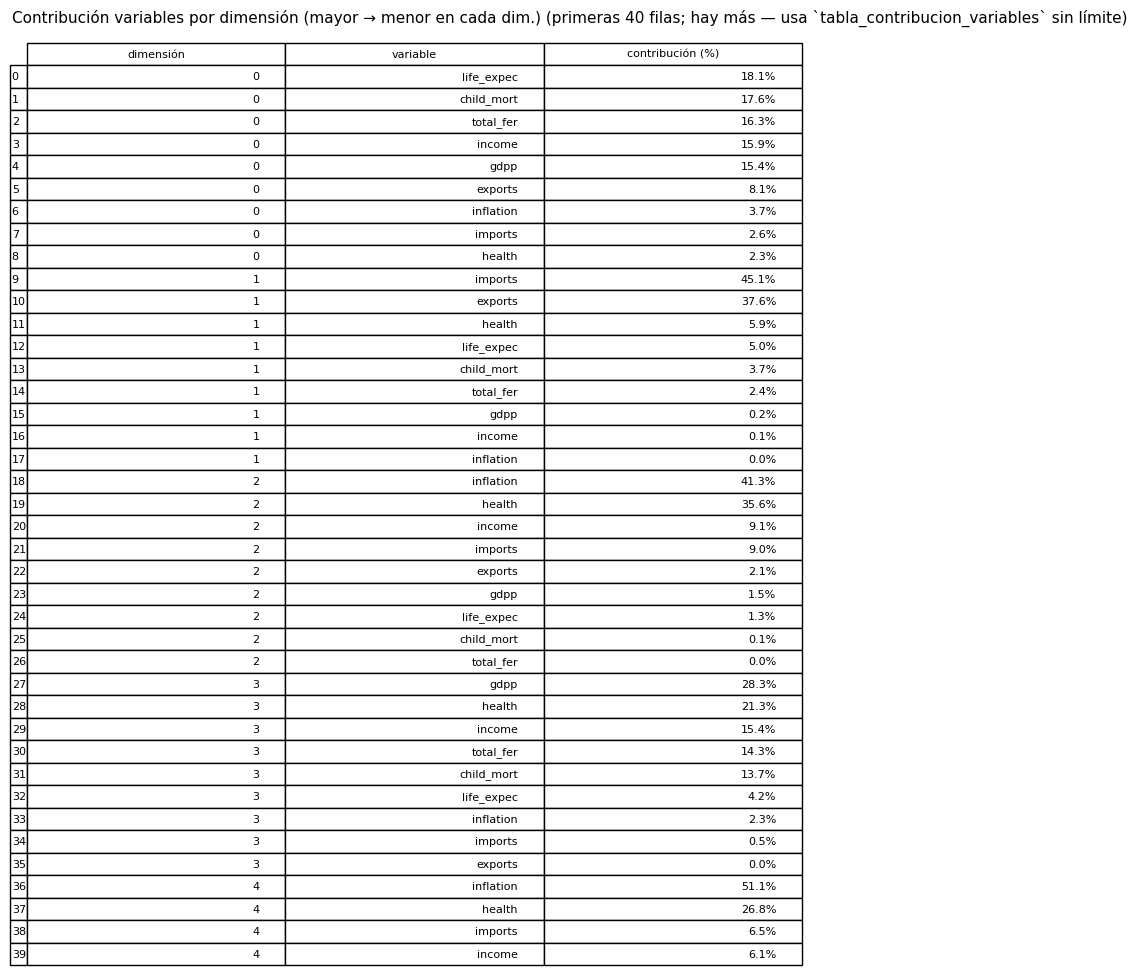

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
vis.plot_tabla_contribucion_variables(ax=ax)
plt.show()